## Домашка 3

#### *«Ты понимаешь, что это значит? Это значит, что эта пакость не работает!» — Назад в будущее*

Эта домашка про метрики в a/b-тестировании. За неё можно получить максимум 12 баллов.

**Дедлайны**  
Мягкий дедлайн: 04.10.2026 23:59 по МСК.   
Жесткий дедлайн: 11.10.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_3). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.


Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_3_data.zip)

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import norm, pearsonr
import math
from pathlib import Path
from zipfile import ZipFile

files = ['data/hw_3_events_data.csv', 'data/hw_3_experimens_history.csv']
if not all(Path(file).exists() for file in files):
    with ZipFile('hw_3_data.zip') as archive:
        for file in files:
            if not Path(file).exists():
                archive.extract(file)

### Warm up

#### 1. Сопоставьте тип эксперимента с продуктовым изменением — 2 балла

a) По-юзерный A/B тест  
b) Свитчбек (по времени)   
c) Региональный A/B тест


1. Новая логика выдачи контента на главной в стриминговом сервисе фильмов и сериалов.
2. Запуск динамического ценообразования в сервисе доставки еды.
3. Тестирование push-уведомления о брошенной корзине в e-commerce приложении.
4. Раскатка в сервисе такси через эксперимент новой схемы комиссий для водителей (старт с одного города).
5. Добавление ипотечного калькулятора с точкой входа в Новостройки на главной сервиса объявлений Недвижимости.
6. Изменение SLA времени доставки в сервисе курьерской доставки (старт с одного города).

In [16]:
pd.Series(['a', 'b', 'a', 'c', 'a', 'c'],
          index=[1, 2, 3, 4, 5, 6], name='Тип теста')


,Тип теста
1,a
2,b
3,a
4,c
5,a
6,c


### Case Study. Дизайн эксперимента в сервисе объявлений жилой недвижимости 🏡

**Легенда**  
Вы работаете продуктовым аналитиком в сервисе объявлений жилой недвижимости. Платформа позволяет пользователям размещать объявления о продаже и аренде жилья (как частным лицам, так и застройщикам), а другим — просматривать и контактировать / оставлять заявки по объявлениям.    
Ваша команда "Новостройки" хочет разместить на главной ипотечный калькулятор с точкой входа напрямую в свой раздел. Цель — увеличить число заявок.

**Гипотеза** — размещение ипотечного калькулятора на главной сервиса увеличит долю пользователей, оставивших заявку в Новостройках, как минимум на 15%, при этом не ухудшит аналогичные метрики в других разделах (Аренда, Вторичка) более чем на 3%.

$$
\Delta_{\mathrm{rel}}=\left(\frac{p_t-p_c}{p_c}\right)\times 100\% \quad \text{(формула эффекта)}
$$

**Ограничения** — вы не можете держать главную в тесте больше 14 дней из-за запланированного календаря экспериментов с другими командами.

**Набор метрик для дизайна.**   
Target — доля пользователей с заполненной заявкой на звонок (Новостройки).   

Guardrails:
- доля пользователей с контактом по объявлению Аренды;
- доля пользователей с контактом по объявлению Вторички;
- доля пользователей с контактом по объявлению из любой категории (подумайте, зачем нужна эта метрика? от какой ловушки она защищает?).   

Informative:
- доля пользователей, перешедших с главной в раздел Аренды;
- доля пользователей, перешедших с главной в раздел Вторички;
- доля пользователей, перешедших с главной в раздел Новостроек;
- доля пользователей с переходами в список объявлений по навигации на главной.

Все доли рассчитываются от набранного объема пользователей в каждой из групп. Пользователи попадают в exposure сразу при посещении главной.

**Для расчетов метрик используйте следующие ивенты:**
- Для target и guardrails — contact_submit.
- Для informative — list_view и source==main_nav.

*В рамках такого эксперимента также имеет смысл смотреть на среднее число контактов / заявок по каждому из разделов и в общем, а не просто на бинарные метрики. Но в данном задании мы сосредоточимся на долях, чтобы не раздувать алгоритм расчета до полного реалистичного пресета метрик.*

In [5]:
df_logs = pd.read_csv('data/hw_3_events_data.csv')
df_logs.head()

,timestamp,user_id,session_id,event,category,source,listing_id
0,2025-06-01 00:00:00,114227,8828585581,main_view,none,none,NaN
1,2025-06-01 00:00:00,212987,8591655166,main_view,none,none,NaN
2,2025-06-01 00:00:00,1413962,2533393268,add_fav,rent_long,other,992874562.0
3,2025-06-01 00:00:00,1221850,2060698550,main_view,none,none,NaN
4,2025-06-01 00:00:00,31469,6550065912,main_view,none,none,NaN


In [6]:
df_exps = pd.read_csv('data/hw_3_experimens_history.csv')
df_exps.head()

,exp_id,days,target_contact_effect_rel,target_contact_p_value,target_contact_p0,target_contact_effect_abs,proxy_card_effect_rel,proxy_card_p_value,proxy_card_p0,proxy_card_effect_abs,proxy_fav_effect_rel,proxy_fav_p_value,proxy_fav_p0,proxy_fav_effect_abs,proxy_form_effect_rel,proxy_form_p_value,proxy_form_p0,proxy_form_effect_abs
0,3937,7,0.000067,0.448527,0.000382,2.562909e-08,0.000814,0.254909,0.014527,0.000012,0.014880,0.443100,0.004335,0.000065,0.054000,0.200074,0.000782,0.000042
1,2806,7,0.000053,0.353007,0.000339,1.793707e-08,0.025588,0.002390,0.012604,0.000323,0.055000,0.007806,0.004289,0.000236,0.042542,0.077772,0.000687,0.000029
2,3457,7,0.000036,0.397718,0.000353,1.255839e-08,0.010437,0.171633,0.013020,0.000136,0.007892,0.486577,0.004187,0.000033,0.028638,0.385118,0.000718,0.000021
3,1002,7,0.000032,0.266510,0.000388,1.246465e-08,0.015525,0.001215,0.012697,0.000197,0.045051,0.000516,0.004062,0.000183,0.025849,0.164273,0.000735,0.000019
4,9070,7,0.000046,0.461855,0.000377,1.722521e-08,0.011572,0.217843,0.013902,0.000161,0.010127,0.317622,0.004349,0.000044,0.036751,0.236595,0.000786,0.000029


Описание данных hw_3_events_data:

- timestamp — дата-время взаимодействия с контентом
- user_id — уникальный идентификатор пользователя
- session_id – уникальный идентификатор сессии
- event — тип события
- category — категория, в которой произошло событие (не приходит для главной)
- source — источник перехода на страницу
- listing_id – уникальный идентификатор объявления

Описание данных hw_3_experimens_history (это история экспериментов именно в разделе Новостройки):

- exp_id — уникальный идентификатор эксперимента
- days — длительность теста
- target_contact_effect_rel — относительный эффект на таргет метрике
- target_contact_p_value — p-value полученного результата для таргет метрики
- target_contact_p0 — значение конверсии таргет метрики в контроле
- target_contact_effect_abs — абсолютный эффект на таргет метрике
- proxy_card_effect_rel — относительный эффект на конверсии просмотра карточки объявления
- proxy_card_p_value — p-value полученного результата для конверсии просмотра карточки объявления
- proxy_card_p0 — значение конверсии просмотра карточки объявления в контроле
- proxy_card_effect_abs — абсолютный эффект на конверсии просмотра карточки объявления
- proxy_fav_effect_rel — относительный эффект на конверсии добавления объявления в избранное
- proxy_fav_p_value — p-value полученного результата для конверсии добавления объявления в избранное
- proxy_fav_p0 — значение конверсии добавления объявления в избранное в контроле
- proxy_fav_effect_abs – абсолютный эффект на конверсии добавления объявления в избранное
- proxy_form_effect_rel — относительный эффект на конверсии открытия формы заявки на звонок по объявлению
- proxy_form_p_value — p-value полученного результата для конверсии открытия формы заявки на звонок по объявлению
- proxy_form_p0 — значение конверсии открытия формы заявки на звонок по объявлению в контроле
- proxy_form_effect_abs — абсолютный эффект на конверсии открытия формы заявки на звонок по объявлению

#### 2. Рассчитайте количество дней, необходимое для детектирования заявленных в гипотезе эффектов (target и guardrails-метрики) — 2 балла
Здесь и далее используйте для расчетов значение alpha = 0.01 (делаем поправку на принятие решения по набору метрик) и beta = 0.2. А также двусторонний критерий — мы заранее не знаем, куда двинутся метрики, поэтому хотим учесть и противоположные эффекты.  

Для метрики "доля пользователей с контактом по объявлению из любой категории" также используйте эффект в 3%.

In [7]:
# your code is here

alpha = 0.01
beta = 0.2
z = norm.ppf(1 - alpha / 2) + norm.ppf(1 - beta)

df_logs['timestamp'] = pd.to_datetime(df_logs['timestamp'])
for column in ['event', 'category', 'source']:
    df_logs[column] = df_logs[column].astype('category')

# Exposure - все, кто открыл главную, независимо от source.
first_visit = (df_logs.loc[df_logs['event'] == 'main_view', ['user_id', 'timestamp']]
               .groupby('user_id')['timestamp'].min())
exposure_users = first_visit.index
total_users = len(exposure_users)
start_day = df_logs['timestamp'].min().normalize()
end_day = df_logs['timestamp'].max().normalize()
days_in_data = (end_day - start_day).days + 1

new_users = first_visit.dt.normalize().value_counts().sort_index()
cum_users = new_users.cumsum()
users_per_day = total_users / days_in_data
n_14 = total_users / 2
print(f'За {days_in_data} дней в exposure попало {total_users:,} пользователей.')
print(f'На одну группу за 14 дней: {n_14:,.0f} пользователей.')

def user_share(event, categories=None, source=None):
    selected = df_logs['event'] == event
    if categories is not None:
        selected &= df_logs['category'].isin(categories)
    if source is not None:
        selected &= df_logs['source'] == source
    users = df_logs.loc[selected, 'user_id'].drop_duplicates()
    return users.isin(exposure_users).sum() / total_users

# Долгосрочную и посуточную аренду считаем вместе.
metrics = [
    ('Новостройки', ['newbuilds'], 0.15),
    ('Аренда', ['rent_long', 'rent_daily'], 0.03),
    ('Вторичка', ['secondary'], 0.03),
    ('Любая категория', None, 0.03)
]

rows = []
for name, categories, effect_rel in metrics:
    p0 = user_share('contact_submit', categories)
    effect_abs = p0 * effect_rel
    n_group = math.ceil(2 * p0 * (1 - p0) * z ** 2 / effect_abs ** 2)

    enough_users = cum_users[cum_users >= 2 * n_group]
    if not enough_users.empty:
        days = (enough_users.index[0] - start_day).days + 1
        method = 'по накопу'
    else:
        days = math.ceil(2 * n_group / users_per_day)
        method = 'по среднему, примерно'

    rows.append([name, p0 * 100, effect_rel * 100, n_group, days, method])

design = pd.DataFrame(rows, columns=[
    'Метрика', 'База, %', 'Эффект, %', 'Пользователей на группу', 'Дней', 'Расчёт'
]).set_index('Метрика')

# Общая доля нужна, чтобы не пропустить потерю контактов при перетоке между разделами.
# Здесь один пользователь учитывается один раз, даже если он оставил контакты в нескольких разделах.
design.round(4)


За 14 дней в exposure попало 1,781,124 пользователей.
На одну группу за 14 дней: 890,562 пользователей.


,"База, %","Эффект, %",Пользователей на группу,Дней,Расчёт
Метрика,,,,,
Новостройки,0.0373,15.0,2783660,44,"по среднему, примерно"
Аренда,4.3348,3.0,572767,6,по накопу
Вторичка,1.4516,3.0,1761940,28,"по среднему, примерно"
Любая категория,5.7396,3.0,426228,4,по накопу


#### 3. Рассчитайте MDE для информативных метрик — 2 балла
В реальности эффекты по информативным критериям, которые мы также хотим включать в пресет метрик, нужно сравнивать на достижимость на основе прошлых экспериментов. Как правило, проделав это упражнение один раз, вы просто сохраняете достижимый трешхолд в базе знаний команды и принимаете решение о включении их в базовый набор. Проверка эффектов для каждого теста не требуется. Однако, стоит делать периодический пересмотр зафиксированных достижимых эффектов, например раз в полгода / год, или при сильных изменениях продукта / рынка.

В данном задании мы с вами не будем опираться на историю тестов, просто потренируемся делать обратный расчет — размера эффекта от заданной длительности (14 дней).

*Для числителя используйте только ивенты с источником main_nav*

In [15]:
def get_mde(p0):
    return math.sqrt(2 * p0 * (1 - p0) * z ** 2 / n_14)

sections = [
    ('Аренда', ['rent_long', 'rent_daily']),
    ('Вторичка', ['secondary']),
    ('Новостройки', ['newbuilds']),
    ('Любой список', None)
]

rows = []
for name, categories in sections:
    # Ограничение main_nav относится к числителю. Знаменатель тот же exposure.
    p0 = user_share('list_view', categories, 'main_nav')
    mde_abs = get_mde(p0)
    mde_rel = mde_abs / p0
    rows.append([name, p0 * 100, mde_abs * 100, mde_rel * 100])

informative_mde = pd.DataFrame(rows, columns=[
    'Переход', 'База, %', 'MDE, п.п.', 'MDE, % от базы'
]).set_index('Переход')
informative_mde.round(3)


,"База, %","MDE, п.п.","MDE, % от базы"
Переход,,,
Аренда,41.506,0.252,0.608
Вторичка,22.396,0.214,0.953
Новостройки,4.457,0.106,2.371
Любой список,54.593,0.255,0.467


#### 4. Выбираем proxy-метрику (шаг 1) — 2 балла
Стало понятно, что за 14 дней мы не успеем замерить эффект по таргету. Что делать? Можно использовать методы снижения дисперсии, а можно попробовать подобрать proxy-метрику. Давайте реализуем второй вариант.

**Для proxy будем использовать 3-х кандидатов:**
- доля пользователей с просмотром карточки объявления в Новостройках;
- доля пользователей, добавивших в избранное объявление в Новостройках;
- доля пользователей, открывших форму заявки в Новостройках — связь с автором объявления в этом разделе предполагает обратный звонок от офиса продаж, поэтому чтобы сделать событие контакта, релевантное другим разделам, нужно ввести свой номер телефона в форму заявки, расположенную на карточке.

Для каждой из proxy-метрик:
- Рассчитайте MDE для заданной длительности — 14 дней;
- По историческому набору экспериментов постройте диаграмму рассеяния зафиксированных эффектов и длительности тестов (пометьте значимые эффекты).

**Для расчетов метрик используйте следующие ивенты:**
- Для proxy — card_view, add_fav, form_start.

,"База, %","MDE, п.п.","MDE, % от базы"
Прокси,,,
Просмотр карточки,1.366,0.059,4.351
Избранное,0.396,0.032,8.124
Открытие формы,0.072,0.014,19.097


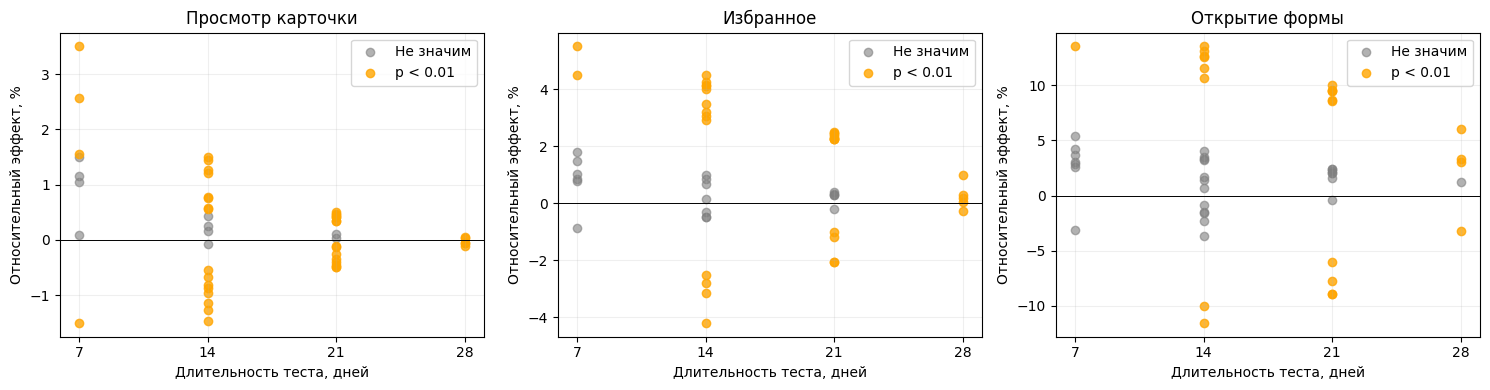

In [9]:
# your code is here

import matplotlib.pyplot as plt

proxy_events = {'card': 'card_view', 'fav': 'add_fav', 'form': 'form_start'}
proxy_names = {'card': 'Просмотр карточки', 'fav': 'Избранное',
               'form': 'Открытие формы'}

rows = []
for key in proxy_events:
    p0 = user_share(proxy_events[key], ['newbuilds'])
    mde_abs = get_mde(p0)
    rows.append([proxy_names[key], p0 * 100, mde_abs * 100, mde_abs / p0 * 100])

proxy_mde = pd.DataFrame(rows, columns=[
    'Прокси', 'База, %', 'MDE, п.п.', 'MDE, % от базы'
]).set_index('Прокси')
display(proxy_mde.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for key, ax in zip(proxy_events, axes):
    effect = df_exps[f'proxy_{key}_effect_rel'] * 100
    significant = df_exps[f'proxy_{key}_p_value'] < alpha
    ax.scatter(df_exps.loc[~significant, 'days'], effect[~significant],
               color='gray', alpha=0.6, label='Не значим')
    ax.scatter(df_exps.loc[significant, 'days'], effect[significant],
               color='orange', alpha=0.8, label='p < 0.01')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(proxy_names[key])
    ax.set_xlabel('Длительность теста, дней')
    ax.set_ylabel('Относительный эффект, %')
    ax.set_xticks([7, 14, 21, 28])
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()


#### 5. Выбираем proxy-метрику (шаг 2) — 2 балла
Для каждой из proxy-метрик по историческому набору экспериментов рассчитайте:
- Binary Sensitivity;
- MSE с таргет-метрикой;
- Корреляцию Пирсона с таргет-метрикой.

In [10]:
target_effect = df_exps['target_contact_effect_rel']
target_significant = df_exps['target_contact_p_value'] < alpha
print(f'Binary Sensitivity таргета: {target_significant.mean():.0%}')

rows = []
for key in proxy_events:
    proxy_effect = df_exps[f'proxy_{key}_effect_rel']
    proxy_significant = df_exps[f'proxy_{key}_p_value'] < alpha

    sensitivity = proxy_significant.sum() / len(df_exps)
    # В лекции MSE и Пирсон считаются по относительным эффектам всех тестов.
    mse = ((proxy_effect - target_effect) ** 2).mean()
    correlation = pearsonr(proxy_effect, target_effect)[0]
    rows.append([proxy_names[key], sensitivity, mse, correlation])

proxy_quality = pd.DataFrame(rows, columns=[
    'Прокси', 'Binary Sensitivity', 'MSE', 'Корреляция Пирсона'
]).set_index('Прокси')
proxy_quality.round(6)


Binary Sensitivity таргета: 40%


,Binary Sensitivity,MSE,Корреляция Пирсона
Прокси,,,
Просмотр карточки,0.80,0.014300,0.150005
Избранное,0.64,0.011042,0.669678
Открытие формы,0.46,0.006551,0.723834
